# Semana 6 — Deep Learning con LSTM

**Objetivo.** Preparar tensores secuenciales, entrenar una LSTM con controles de generalización y comprobar si aporta valor frente a ARIMA, LightGBM y un baseline estacional.

- **Dataset:** `data/06_opsd/germany_energy.csv`
- **Duración:** 5 horas
- **Target:** `DE_load_actual_entsoe_transparency` (MW)
- **Seed:** 42
- **Dispositivo:** CPU

**Contrato de secciones:** Sección 0: Configuración y contrato de datos; Sección 1: Análisis previo; Sección 2: Estrategia de validación; Sección 3: Modelado; Sección 4: Análisis posterior; Sección 5: Lecciones metodológicas; Sección 6: Ejercicios.

### Caso de negocio: operador del sistema eléctrico alemán

Un operador del sistema (TSO) alemán debe planificar la generación y garantizar la seguridad de suministro con antelación. Pronosticar la carga eléctrica nacional (`DE_load_actual_entsoe_transparency`) permite reservar capacidad, integrar renovables y operar el mercado con margen. El error tiene coste: subestimar la demanda puede obligar a activar reservas de emergencia o comprar energía cara en intradía; sobreestimarla encarece la operación sin necesidad real.

**Pregunta guía del notebook:** ¿Deep learning justifica su coste frente a baselines fuertes (ARIMA, LightGBM y seasonal naive) en este protocolo?

La respuesta se construye con evaluación justa: los cuatro modelos compiten sobre los mismos folds (sección 2) y se comparan con las mismas métricas (sección 3). La decisión ejecutiva se resume en la sección 4.10.

> *Este notebook modela carga eléctrica nacional agregada (MW/hora), no consumo individual de hogares ni decisiones de plantas generadoras específicas. Las conclusiones aplican a despacho y planificación de red, no a intervenciones sobre consumidores o productores individuales.*

### 0.1 Imports y reproducibilidad

PyTorch se configura en CPU y con una semilla global.

In [1]:
from __future__ import annotations
from pathlib import Path
import copy, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.set_num_threads(4)
DEVICE=torch.device("cpu"); warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"]=(12,4)
print(torch.__version__,DEVICE)

2.13.0+cpu cpu


In [2]:
# --- Constantes con nombre del protocolo (documentación ejecutable) ---
HORAS_POR_DIA = 24
DIAS_ENTRENAMIENTO = 365   # historia de entrenamiento por fold: un año
DIAS_VALIDACION = 7        # ventana de test: un ciclo semanal completo
HORAS_VALIDACION = HORAS_POR_DIA * DIAS_VALIDACION  # 168 horas
print(f"Horizonte de validación: {HORAS_VALIDACION} horas = {DIAS_VALIDACION} días")

Horizonte de validación: 168 horas = 7 días


### 0.2 Ruta portable

Carga desde raíz o notebooks.

In [3]:
CANDIDATES=[Path("data/06_opsd/germany_energy.csv"),Path("../data/06_opsd/germany_energy.csv")]
DATA_PATH=next((p for p in CANDIDATES if p.exists()),None); assert DATA_PATH
print(DATA_PATH.resolve(),f"{DATA_PATH.stat().st_size/2**20:.1f} MiB")

/home/enrique/Escritorio/Curso_pronostico_series_temporales/course-timeseries-benchmarks-pro/data/06_opsd/germany_energy.csv 14.2 MiB


### 0.3 Carga y dimensiones

Se esperan 50,401 filas y 43 columnas.

In [4]:
raw=pd.read_csv(DATA_PATH,parse_dates=["ds_utc"])
assert raw.shape==(50_401,43),raw.shape
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 43 columns):
 #   Column                                           Non-Null Count  Dtype              
---  ------                                           --------------  -----              
 0   ds_utc                                           50401 non-null  datetime64[ns, UTC]
 1   cet_cest_timestamp                               50401 non-null  object             
 2   DE_load_actual_entsoe_transparency               50400 non-null  float64            
 3   DE_load_forecast_entsoe_transparency             50376 non-null  float64            
 4   DE_solar_capacity                                43800 non-null  float64            
 5   DE_solar_generation_actual                       50297 non-null  float64            
 6   DE_solar_profile                                 43696 non-null  float64            
 7   DE_wind_capacity                                 43800 non-null  float64    

### 0.4 Target y covariables

Se usan variables nacionales con cobertura alta. El precio se omite por cobertura corta.

**Nota sobre la covariable clave.** `DE_load_forecast_entsoe_transparency` es el pronóstico oficial de carga publicado por el operador de red. Está legítimamente disponible ex-ante (no es oracle), pero su presencia condiciona fuertemente el resultado: un modelo que la usa puede estar "aprendiendo a corregir el pronóstico oficial" más que "aprendiendo la carga desde cero". En producción es una ventaja informativa legítima, pero la atribución de cualquier victoria debe documentarse explícitamente.

In [5]:
TARGET="DE_load_actual_entsoe_transparency"
FEATURES=[TARGET,"DE_load_forecast_entsoe_transparency","DE_solar_generation_actual","DE_wind_generation_actual","DE_wind_offshore_generation_actual","DE_wind_onshore_generation_actual"]
raw[["ds_utc",*FEATURES]].notna().sum()

ds_utc                                  50401
DE_load_actual_entsoe_transparency      50400
DE_load_forecast_entsoe_transparency    50376
DE_solar_generation_actual              50297
DE_wind_generation_actual               50326
DE_wind_offshore_generation_actual      50326
DE_wind_onshore_generation_actual       50328
dtype: int64

### 0.5 Rango temporal

UTC evita ambigüedad DST.

In [6]:
assert raw.ds_utc.is_monotonic_increasing and raw.ds_utc.is_unique
print(raw.ds_utc.min(),raw.ds_utc.max(),raw.ds_utc.diff().value_counts().head())

2014-12-31 23:00:00+00:00 2020-09-30 23:00:00+00:00 ds_utc
0 days 01:00:00    50400
Name: count, dtype: int64


### 0.6 Gaps temporales

Rejilla horaria completa.

In [7]:
expected=pd.date_range(raw.ds_utc.min(),raw.ds_utc.max(),freq="h",tz="UTC"); print("gaps",len(expected.difference(raw.ds_utc)))

gaps 0


### 0.7 Nulos

Se cuantifican antes de seleccionar periodo.

In [8]:
quality=raw[["ds_utc",*FEATURES]].isna().sum().to_frame("missing"); quality["pct"]=100*quality.missing/len(raw); quality

,missing,pct
ds_utc,0,0.000000
DE_load_actual_entsoe_transparency,1,0.001984
DE_load_forecast_entsoe_transparency,25,0.049602
DE_solar_generation_actual,104,0.206345
DE_wind_generation_actual,75,0.148807
DE_wind_offshore_generation_actual,75,0.148807
DE_wind_onshore_generation_actual,73,0.144838


### 0.8 Periodo de laboratorio

Se usan los últimos 730 días con cobertura estable. Es un recorte temporal deliberado, no muestreo aleatorio.

In [9]:
df=raw.set_index("ds_utc")[FEATURES].tail(24*730).copy(); print(df.index.min(),df.index.max(),df.shape,df.isna().sum().to_dict())

2018-10-02 00:00:00+00:00 2020-09-30 23:00:00+00:00 (17520, 6) {'DE_load_actual_entsoe_transparency': 0, 'DE_load_forecast_entsoe_transparency': 0, 'DE_solar_generation_actual': 0, 'DE_wind_generation_actual': 0, 'DE_wind_offshore_generation_actual': 0, 'DE_wind_onshore_generation_actual': 0}


### 0.9 Imputación causal

Forward-fill limitado a 24 horas; remanentes con mediana del bloque de entrenamiento en cada fold. Aquí solo se inspecciona.

In [10]:
audit=df.ffill(limit=24); audit.isna().sum()

DE_load_actual_entsoe_transparency      0
DE_load_forecast_entsoe_transparency    0
DE_solar_generation_actual              0
DE_wind_generation_actual               0
DE_wind_offshore_generation_actual      0
DE_wind_onshore_generation_actual       0
dtype: int64

### 0.10 Estadísticos

Unidades de energía/potencia según OPSD; target reportado en MW.

In [11]:
df[TARGET].describe(percentiles=[.01,.25,.5,.75,.99]).to_frame().T

,count,mean,std,min,1%,25%,50%,75%,99%,max
DE_load_actual_entsoe_transparency,17520.0,55143.539384,9987.793779,31923.0,35939.57,47005.75,54708.5,63429.25,73864.81,76925.0


## 1. Análisis previo (pre-modeling)

EDA, estacionalidad, estacionariedad y cambios sobre el periodo de cobertura estable.

### 1.1 Serie completa

Demanda alemana horaria.

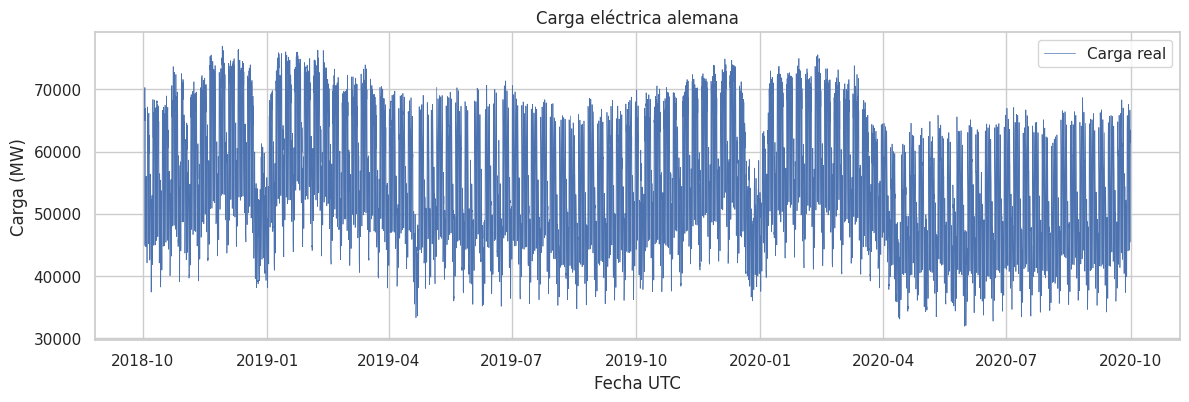

In [12]:
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(df.index,df[TARGET],lw=.5,label="Carga real"); ax.set(title="Carga eléctrica alemana",xlabel="Fecha UTC",ylabel="Carga (MW)"); ax.legend(); plt.show()

### 1.2 Zoom semanal

Ciclo intradiario y semanal.

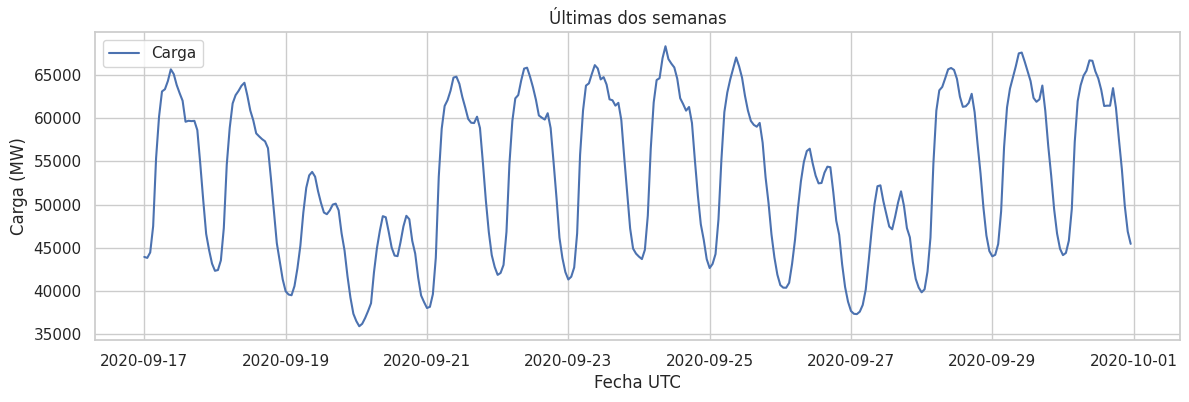

In [13]:
z=df.loc[df.index[-24*14]:,TARGET]; fig,ax=plt.subplots(figsize=(14,4)); ax.plot(z.index,z,label="Carga"); ax.set(title="Últimas dos semanas",xlabel="Fecha UTC",ylabel="Carga (MW)"); ax.legend(); plt.show()

### 1.3 Perfil horario

Media y mediana.

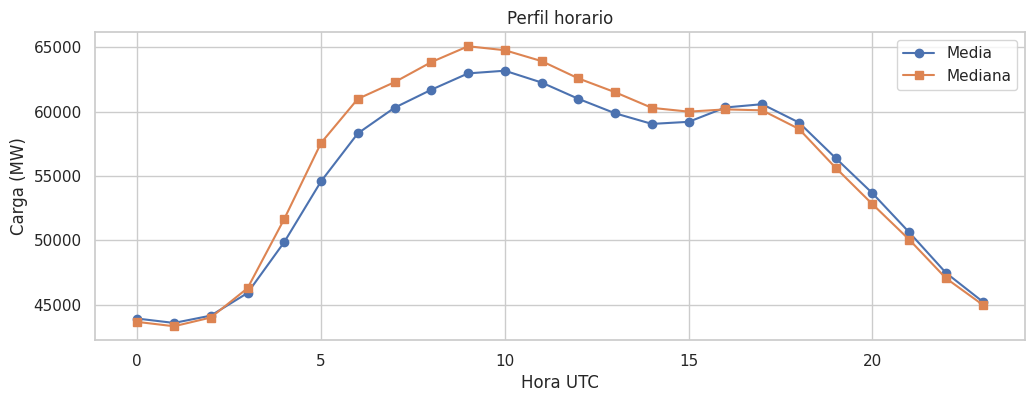

In [14]:
p=df.assign(hour=df.index.hour).groupby("hour")[TARGET].agg(["mean","median"]); fig,ax=plt.subplots(); ax.plot(p.index,p["mean"],marker="o",label="Media"); ax.plot(p.index,p["median"],marker="s",label="Mediana"); ax.set(title="Perfil horario",xlabel="Hora UTC",ylabel="Carga (MW)"); ax.legend(); plt.show()

### 1.4 Perfil semanal

Diferencia laboral-fin de semana.

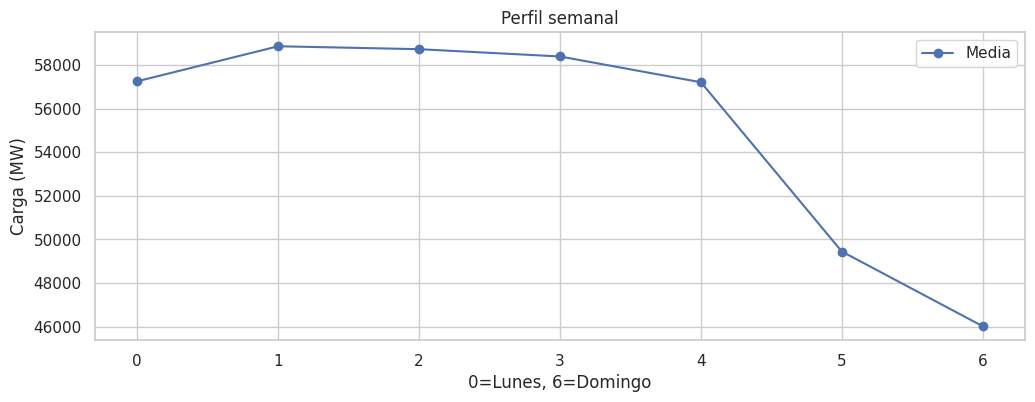

In [15]:
p=df.assign(dow=df.index.dayofweek).groupby("dow")[TARGET].mean(); fig,ax=plt.subplots(); ax.plot(p.index,p,marker="o",label="Media"); ax.set(title="Perfil semanal",xlabel="0=Lunes, 6=Domingo",ylabel="Carga (MW)"); ax.legend(); plt.show()

### 1.5 Correlaciones

Covariables observadas/pronosticadas.

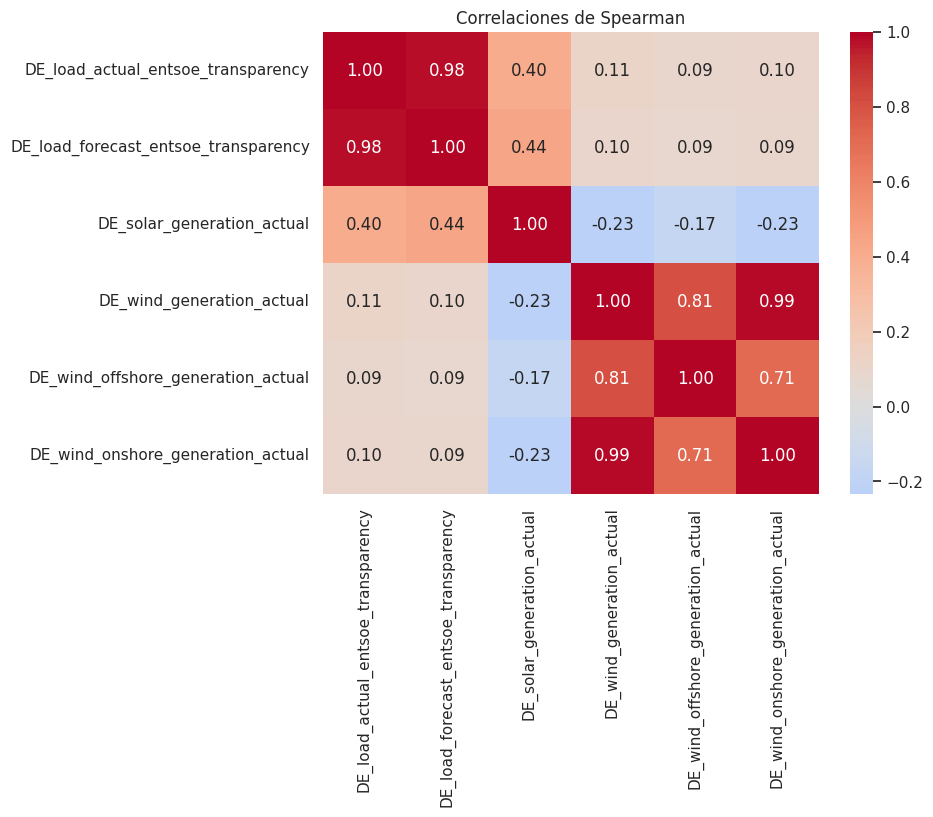

In [16]:
corr=df.corr(method="spearman"); fig,ax=plt.subplots(figsize=(8,6)); sns.heatmap(corr,annot=True,fmt=".2f",center=0,cmap="coolwarm",ax=ax); ax.set(title="Correlaciones de Spearman"); plt.show()

### 1.6 STL semanal

Periodo 168.

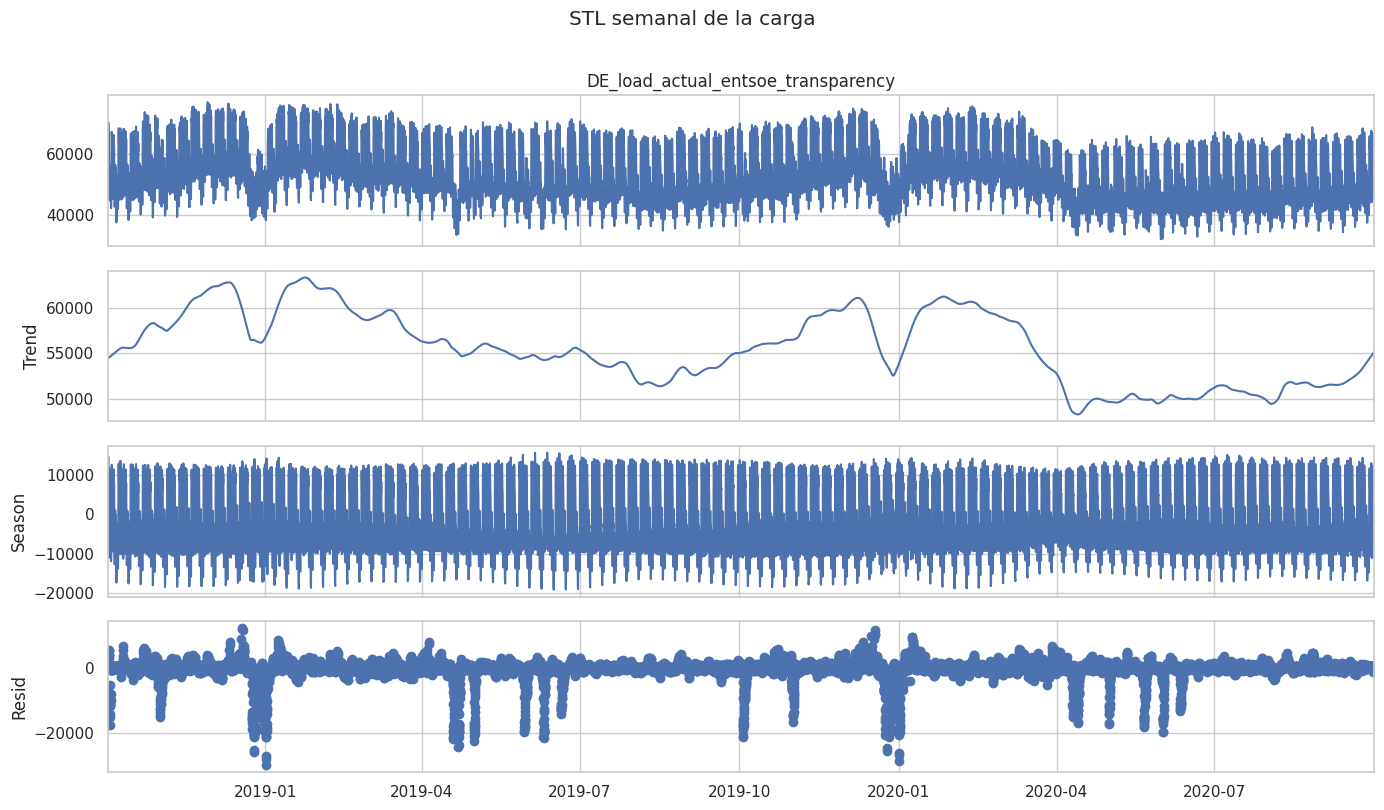

In [17]:
eda=df[TARGET].ffill().bfill(); stl=STL(eda,period=168,robust=True).fit(); fig=stl.plot(); fig.set_size_inches(14,8); fig.suptitle("STL semanal de la carga",y=1.01); plt.tight_layout(); plt.show()

### 1.7 Estacionariedad

ADF H₀: raíz unitaria. KPSS H₀: estacionariedad. α=0.05.

### 1.8 Tests

Reporte completo.

In [18]:
def stationarity(x: pd.Series,label: str)->pd.DataFrame:
    a=adfuller(x.dropna(),autolag="AIC"); k=kpss(x.dropna(),regression="c",nlags="auto"); return pd.DataFrame([{"test":"ADF","serie":label,"H0":"raíz unitaria","stat":a[0],"p_value":a[1],"decision":"rechazar H0" if a[1]<.05 else "no rechazar H0"},{"test":"KPSS","serie":label,"H0":"estacionaria","stat":k[0],"p_value":k[1],"decision":"rechazar H0" if k[1]<.05 else "no rechazar H0"}])
stationarity(eda,"nivel")

,test,serie,H0,stat,p_value,decision
0,ADF,nivel,raíz unitaria,-14.056538,3.110044e-26,rechazar H0
1,KPSS,nivel,estacionaria,4.588423,1.000000e-02,rechazar H0


### 1.9 Diferencia semanal

Diferencia 168.

In [19]:
d168=eda.diff(168).dropna(); stationarity(d168,"diferencia semanal")

,test,serie,H0,stat,p_value,decision
0,ADF,diferencia semanal,raíz unitaria,-11.065831,4.684428e-20,rechazar H0
1,KPSS,diferencia semanal,estacionaria,0.040545,1.000000e-01,no rechazar H0


### 1.10 ACF/PACF

Dependencia residual.

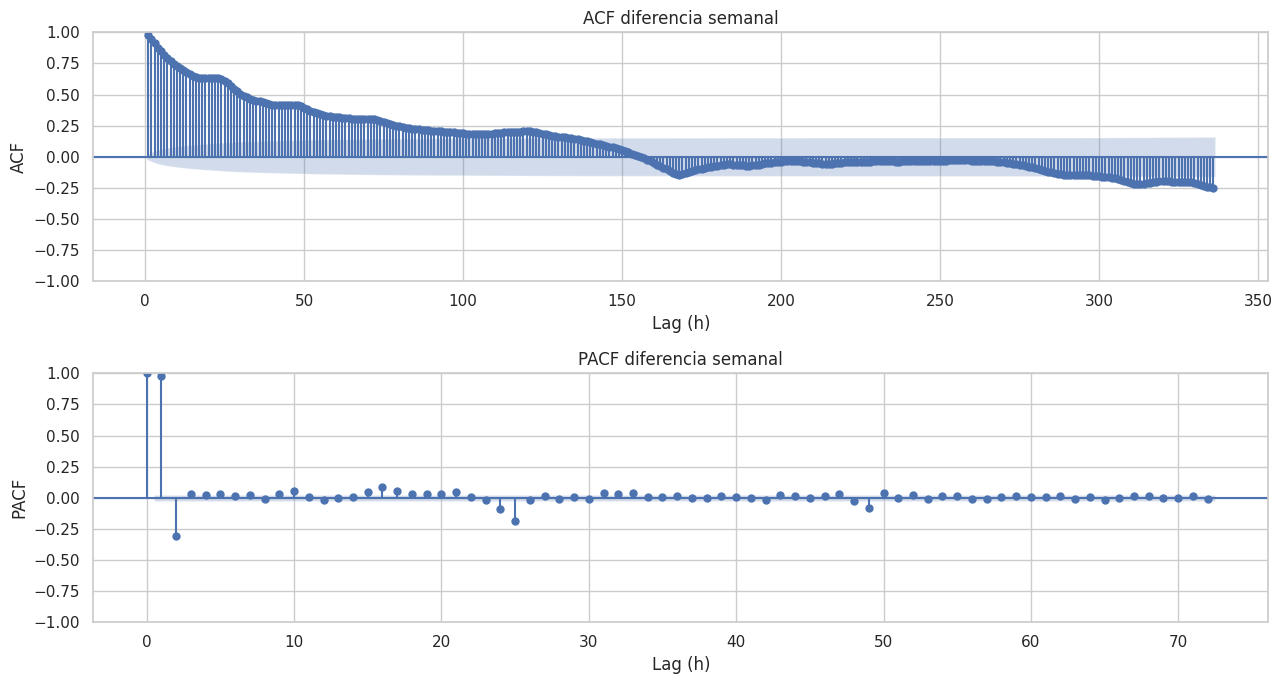

In [20]:
fig,axes=plt.subplots(2,1,figsize=(13,7)); plot_acf(d168.tail(8000),lags=336,zero=False,ax=axes[0]); plot_pacf(d168.tail(8000),lags=72,method="ywm",ax=axes[1]); axes[0].set(title="ACF diferencia semanal",xlabel="Lag (h)",ylabel="ACF"); axes[1].set(title="PACF diferencia semanal",xlabel="Lag (h)",ylabel="PACF"); plt.tight_layout(); plt.show()

### 1.11 Outliers

MAD sobre residuos STL.

In [21]:
med=np.median(stl.resid); mad=np.median(np.abs(stl.resid-med)); rz=.6745*(stl.resid-med)/mad; out=stl.resid[np.abs(rz)>4.5]; print("outliers",len(out))

outliers 1272


### 1.12 CUSUM

Cambio estructural descriptivo.

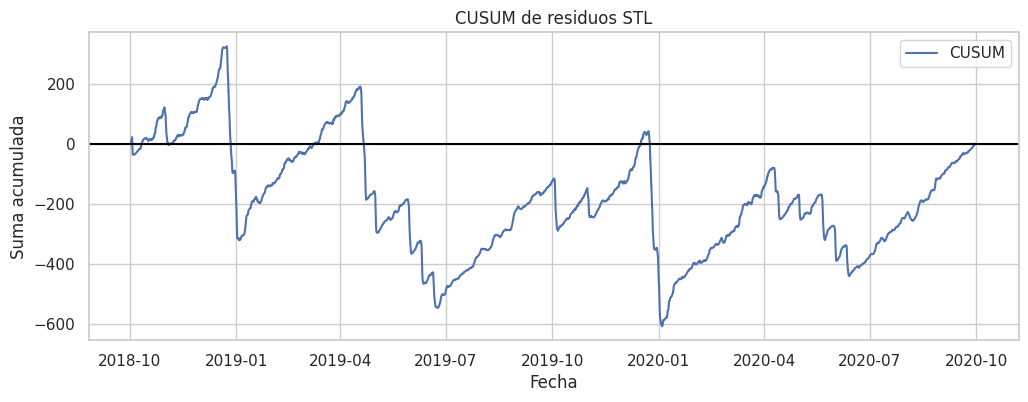

In [22]:
z=(stl.resid-stl.resid.mean())/stl.resid.std(); cs=z.cumsum(); fig,ax=plt.subplots(); ax.plot(cs.index,cs,label="CUSUM"); ax.axhline(0,color="black"); ax.set(title="CUSUM de residuos STL",xlabel="Fecha",ylabel="Suma acumulada"); ax.legend(); plt.show()

## 2. Estrategia de validación

Tres ventanas de validación de 7 días al final del periodo. Cada fold entrena con los 365 días previos y valida los siguientes 168 puntos. Siete días capturan un ciclo semanal completo y simulan reentrenamiento incremental.

### 2.1 Folds

Ventana móvil de 365 días, test 7 días, orígenes separados 7 días.

> **Pausa para pensar.** Antes de ejecutar la celda de folds: ¿qué información podría "filtrarse" del futuro en un esquema train/test temporal? Pista: cualquier escalado, imputación o selección de características que toque datos del test. ¿Qué propiedad de los folds de 2.1 evita ese riesgo?

In [23]:
# --- Partición temporal: 365 días de train, 168 h de test, orígenes separados 7 días ---
H=168; TRAIN=24*365; n=len(df); origins=[n-H*3,n-H*2,n-H]; folds=[{"fold":i+1,"train_start":o-TRAIN,"train_end":o,"test_start":o,"test_end":o+H} for i,o in enumerate(origins)]; pd.DataFrame(folds)

,fold,train_start,train_end,test_start,test_end
0,1,8256,17016,17016,17184
1,2,8424,17184,17184,17352
2,3,8592,17352,17352,17520


In [24]:
# --- Aserciones anti-leakage sobre la partición temporal ---
for f in folds:
    assert f["train_end"] == f["test_start"], "train debe terminar donde empieza test"
    assert f["test_end"] - f["test_start"] == H, "test debe durar 168 horas"
    assert f["test_end"] <= n, "test no debe exceder los datos disponibles"
print(f"Folds OK: {len(folds)} ventanas de {H} h, contiguas y sin solapamiento.")

Folds OK: 3 ventanas de 168 h, contiguas y sin solapamiento.


### 2.2 Diagrama

Train azul, validación negra.

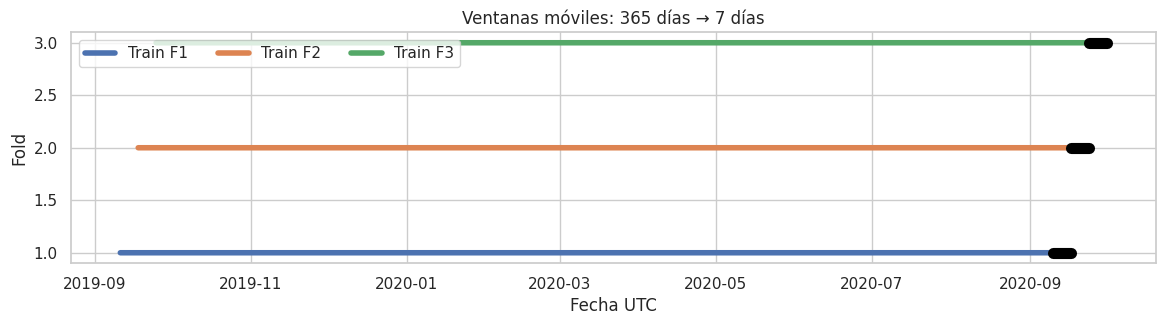

In [25]:
fig,ax=plt.subplots(figsize=(14,3));
for f in folds:
    ax.plot(df.index[f["train_start"]:f["train_end"]],[f["fold"]]*TRAIN,lw=4,label=f"Train F{f['fold']}"); ax.plot(df.index[f["test_start"]:f["test_end"]],[f["fold"]]*H,lw=8,color="black")
ax.set(title="Ventanas móviles: 365 días → 7 días",xlabel="Fecha UTC",ylabel="Fold"); ax.legend(ncol=3); plt.show()

### 2.3 Preparación causal

Imputación y scaler se ajustan en train.

In [26]:
def prepare_fold(f: dict)->tuple[pd.DataFrame,pd.DataFrame,StandardScaler]:
    # --- Imputación causal (ffill 24 h) y scaler ajustado SOLO con train: anti-leakage ---
    tr=df.iloc[f["train_start"]:f["train_end"]].copy(); te=df.iloc[f["test_start"]:f["test_end"]].copy(); tr=tr.ffill(limit=24); med=tr.median(); tr=tr.fillna(med); te=te.ffill(limit=24).fillna(med); scaler=StandardScaler().fit(tr); return pd.DataFrame(scaler.transform(tr),index=tr.index,columns=tr.columns),pd.DataFrame(scaler.transform(te),index=te.index,columns=te.columns),scaler
prepare_fold(folds[0])[0].shape

(8760, 6)

### 2.4 Forma tensorial

(muestras, timesteps, features). Lookback 168 y target siguiente hora.

**Analogía del tensor 3D.** Mientras una fila tabular es una "foto" del momento, cada muestra de la LSTM es un "clip" de la última semana: 168 fotogramas horarios (timesteps) con 6 canales (features: carga, pronóstico de carga, solar, eólica total, eólica offshore y eólica onshore). La red lee el clip en orden temporal y devuelve un único valor: la carga de la hora siguiente.

**¿Por qué la ventana define el horizonte?** El modelo solo ve 168 horas de historia y pronostica +1 h. El horizonte operativo de 7 días lo define la estrategia de validación (sección 2), que evalúa esa capacidad sobre ventanas de test de 168 horas. La celda 3.5 explica que la evaluación es one-step: en cada hora del test se actualiza el lookback con la observación real, no con la predicción previa.

In [27]:
LOOKBACK=168
# --- Ventanas deslizantes: cada muestra es una ventana de 168 h; el objetivo es la hora siguiente ---
def sequences(values: np.ndarray,lookback: int=LOOKBACK,stride: int=3)->tuple[np.ndarray,np.ndarray]:
    xs=[]; ys=[]
    for i in range(lookback,len(values),stride): xs.append(values[i-lookback:i]); ys.append(values[i,0])
    return np.asarray(xs,dtype=np.float32),np.asarray(ys,dtype=np.float32)
tr0,_,_=prepare_fold(folds[0]); Xdemo,ydemo=sequences(tr0.values); print(Xdemo.shape,ydemo.shape)

(2864, 168, 6) (2864,)


In [28]:
# --- Lectura didáctica del tensor 3D generado ---
n_muestras, n_timesteps, n_features = Xdemo.shape
print(f"Tensor 3D: {n_muestras} muestras (batch) x {n_timesteps} timesteps (ventana de {LOOKBACK} h) x {n_features} features")
print("Cada muestra resume una semana de historia; el objetivo asociado es la carga de la hora siguiente.")

Tensor 3D: 2864 muestras (batch) x 168 timesteps (ventana de 168 h) x 6 features
Cada muestra resume una semana de historia; el objetivo asociado es la carga de la hora siguiente.


## 3. Modelado

> **Methodology Card — Cuándo usar DL**  
> Use LSTM si hay suficiente historia, múltiples covariables y patrones no lineales. No la use por defecto con pocos datos, baja latencia extrema o cuando seasonal naive/boosting ya resuelven el problema. Compare precisión, estabilidad y coste.

### 3.1 Métricas

$$MAE=n^{-1}\sum|e_t|,\quad RMSE=\sqrt{n^{-1}\sum e_t^2},\quad MASE=MAE/\mathrm{mean}|y_t-y_{t-168}|.$$

### 3.2 Helper métricas

Escala semanal en train original.

In [29]:
def metrics(a: np.ndarray,p: np.ndarray,train_y: pd.Series)->dict[str,float]:
    # --- Métricas en escala original; MASE normaliza con el error del seasonal naive (t-168) del train ---
    e=a-p; scale=train_y.diff(168).abs().dropna().mean(); return {"MAE":float(np.mean(np.abs(e))),"RMSE":float(np.sqrt(np.mean(e**2))),"MASE":float(np.mean(np.abs(e))/scale),"WAPE_pct":float(100*np.sum(np.abs(e))/np.sum(np.abs(a)))}

### 3.3 Arquitectura LSTM

Una capa, hidden 32 y cabeza lineal.

In [30]:
class LoadLSTM(nn.Module):
    # --- Arquitectura mínima: capa LSTM con 32 unidades ocultas + cabeza lineal de 1 salida ---
    def __init__(self,n_features: int,hidden: int=32)->None:
        super().__init__(); self.lstm=nn.LSTM(n_features,hidden,batch_first=True); self.head=nn.Linear(hidden,1)
    # --- forward: recorre la secuencia completa y pronostica con el último timestep ---
    def forward(self,x: torch.Tensor)->torch.Tensor:
        out,_=self.lstm(x); return self.head(out[:,-1]).squeeze(-1)
print(LoadLSTM(len(FEATURES)))

LoadLSTM(
  (lstm): LSTM(6, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=1, bias=True)
)


### 3.4 Early stopping

Helper con scheduler ReduceLROnPlateau.

In [31]:
def train_lstm(X: np.ndarray,y: np.ndarray,max_epochs: int=12)->tuple[LoadLSTM,pd.DataFrame]:
    # --- Partición interna 85/15 para early stopping; el shuffle usa la seed global ---
    cut=int(.85*len(X)); train_ds=TensorDataset(torch.from_numpy(X[:cut]),torch.from_numpy(y[:cut])); val_x=torch.from_numpy(X[cut:]); val_y=torch.from_numpy(y[cut:]); loader=DataLoader(train_ds,batch_size=128,shuffle=True,generator=torch.Generator().manual_seed(SEED)); model=LoadLSTM(X.shape[2]).to(DEVICE); opt=torch.optim.Adam(model.parameters(),lr=1e-3); sched=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,mode="min",factor=.5,patience=2); loss_fn=nn.MSELoss(); best=np.inf; state=None; patience=0; hist=[]
    # --- Bucle de entrenamiento: early stopping sobre val_loss y reducción de LR ---
    for epoch in range(max_epochs):
        model.train(); losses=[]
        for xb,yb in loader: opt.zero_grad(); loss=loss_fn(model(xb.to(DEVICE)),yb.to(DEVICE)); loss.backward(); opt.step(); losses.append(loss.item())
        model.eval()
        with torch.no_grad(): val=float(loss_fn(model(val_x.to(DEVICE)),val_y.to(DEVICE)))
        sched.step(val); hist.append({"epoch":epoch+1,"train_loss":np.mean(losses),"val_loss":val,"lr":opt.param_groups[0]["lr"]})
        if val<best-1e-5: best=val; state=copy.deepcopy(model.state_dict()); patience=0
        else: patience+=1
        if patience>=4: break
    # --- Restauramos los pesos del mejor estado (menor val_loss) ---
    model.load_state_dict(state); return model,pd.DataFrame(hist)

### 3.5 Predicción secuencial

Para cada hora del test se usa el lookback real disponible: evaluación one-step con actualización observada.

In [32]:
def test_sequences(tr_scaled: pd.DataFrame,te_scaled: pd.DataFrame)->np.ndarray:
    # --- Evaluación one-step: cada hora del test se pronostica con el lookback real observado ---
    joined=pd.concat([tr_scaled.tail(LOOKBACK),te_scaled]); xs=[]
    for i in range(LOOKBACK,len(joined)): xs.append(joined.values[i-LOOKBACK:i])
    return np.asarray(xs,dtype=np.float32)

### 3.6 Entrenamiento por fold

LSTM, LightGBM, ARIMA y seasonal naive.

> **Pausa para pensar.** Los cuatro modelos se entrenan con los mismos folds y se evalúan con las mismas métricas. Antes de ver el resumen (3.7): ¿qué modelo esperas que gane en MASE? ¿La ventaja esperada compensa el coste adicional de entrenar una LSTM (épocas, memoria, parámetros)?

**Consideración adicional:** la LSTM tiene miles de parámetros, requiere entrenamiento por épocas y memoria para escalar; LightGBM entrena en segundos y es interpretable vía importancia de features. La pregunta no es solo "¿cuál tiene menor MASE?" sino "¿la diferencia de MASE justifica el costo de mantener una arquitectura secuencial en producción?" Si la mejora es marginal, la respuesta operativa suele ser que no.

In [33]:
# --- 3.6 Entrenamiento y evaluación por fold: mismo protocolo para los cuatro modelos ---
rows=[]; predictions={}; histories={}; t0=time.time()
for f in folds:
    # --- Cada fold: preparación causal, entrenamiento LSTM y predicción one-step ---
    tr_s,te_s,scaler=prepare_fold(f); tr_orig=df.iloc[f["train_start"]:f["train_end"]].ffill().bfill(); te_orig=df.iloc[f["test_start"]:f["test_end"]].ffill().bfill(); X,y=sequences(tr_s.values,stride=3); model,hist=train_lstm(X,y); histories[f["fold"]]=hist; Xt=test_sequences(tr_s,te_s)
    model.eval()
    with torch.no_grad(): p_scaled=model(torch.from_numpy(Xt)).numpy()
    dummy=np.zeros((len(p_scaled),len(FEATURES))); dummy[:,0]=p_scaled; p_lstm=scaler.inverse_transform(dummy)[:,0]
    # LightGBM usa lags + covariables contemporáneas observadas/pronosticadas
    base=pd.concat([tr_orig.tail(LOOKBACK),te_orig]); tab=base.copy()
    for lag in [1,24,168]: tab[f"lag_{lag}"]=tab[TARGET].shift(lag)
    tab["hour_sin"]=np.sin(2*np.pi*tab.index.hour/24); tab["hour_cos"]=np.cos(2*np.pi*tab.index.hour/24); tab["dow_sin"]=np.sin(2*np.pi*tab.index.dayofweek/7); tab["dow_cos"]=np.cos(2*np.pi*tab.index.dayofweek/7)
    feats=[*FEATURES[1:],"lag_1","lag_24","lag_168","hour_sin","hour_cos","dow_sin","dow_cos"]; train_tab=tab.iloc[:LOOKBACK].dropna(); test_tab=tab.iloc[LOOKBACK:]
    # Para LightGBM se amplía train con último año tabular
    full=tr_orig.copy()
    for lag in [1,24,168]: full[f"lag_{lag}"]=full[TARGET].shift(lag)
    full["hour_sin"]=np.sin(2*np.pi*full.index.hour/24); full["hour_cos"]=np.cos(2*np.pi*full.index.hour/24); full["dow_sin"]=np.sin(2*np.pi*full.index.dayofweek/7); full["dow_cos"]=np.cos(2*np.pi*full.index.dayofweek/7); full=full.dropna()
    gbm=LGBMRegressor(n_estimators=180,learning_rate=.05,num_leaves=31,random_state=SEED,n_jobs=-1,verbosity=-1).fit(full[feats],full[TARGET]); p_gbm=gbm.predict(test_tab[feats])
    ar=ARIMA(tr_orig[TARGET].tail(24*90),order=(2,1,2)).fit(); p_ar=np.asarray(ar.forecast(H)); p_sn=np.asarray([tr_orig[TARGET].get(t-pd.Timedelta(hours=168),tr_orig[TARGET].iloc[-1]) for t in te_orig.index])
    for name,p in [("LSTM",p_lstm),("LightGBM",p_gbm),("ARIMA",p_ar),("SeasonalNaive",p_sn)]: predictions[(f["fold"],name)]=pd.Series(p,index=te_orig.index); rows.append({"fold":f["fold"],"model":name,**metrics(te_orig[TARGET].values,p,tr_orig[TARGET])})
print("segundos",round(time.time()-t0,1)); scores=pd.DataFrame(rows); scores

segundos 16.6


,fold,model,MAE,RMSE,MASE,WAPE_pct
0,1,LSTM,1279.298305,1722.266402,0.527024,2.478033
1,1,LightGBM,547.163750,700.562831,0.225411,1.059870
2,1,ARIMA,7863.946731,9051.843768,3.239658,15.232662
3,1,SeasonalNaive,744.708333,970.708201,0.306793,1.442519
4,2,LSTM,1410.191804,1987.390036,0.582413,2.689873
5,2,LightGBM,544.974232,774.562786,0.225076,1.039512
6,2,ARIMA,8082.606481,9110.911923,3.338141,15.417184
7,2,SeasonalNaive,1073.732143,1269.627596,0.443455,2.048093
8,3,LSTM,1490.715040,1964.426678,0.618459,2.752060
9,3,LightGBM,604.273960,791.062093,0.250698,1.115571


### 3.7 Resumen

Media y desviación por fold.

> **Lectura operativa (anticipando 4.10):** un MASE de 0.234 en LightGBM significa que su error es el 23.4 % del que cometería repetir la misma hora de la semana pasada. Para una red con carga media del orden de decenas de GW, incluso una reducción marginal del error en MW puede traducirse en menos reservas de emergencia contratadas a precio elevado.

In [34]:
summary=scores.groupby("model")[["MAE","RMSE","MASE","WAPE_pct"]].agg(["mean","std"]).sort_values(("MASE","mean")); summary

MAE                     RMSE                  MASE  \
                      mean         std         mean         std      mean   
model                                                                       
LightGBM        565.470648   33.622482   755.395903   48.198092  0.233728   
SeasonalNaive  1195.720238  522.791466  1417.015108  535.437204  0.494681   
LSTM           1393.401716  106.703745  1891.361038  146.889673  0.575966   
ARIMA          7896.263509  172.470498  8982.154771  174.378659  3.263284   

                          WAPE_pct            
                    std       mean       std  
model                                         
LightGBM       0.014697   1.071651  0.039374  
SeasonalNaive  0.218062   2.251969  0.928333  
LSTM           0.046057   2.639989  0.143663  
ARIMA          0.066281  14.981018  0.602764

In [35]:
# --- Lectura ejecutiva de la tabla de resumen ---
mase_lgbm = summary.loc["LightGBM", ("MASE", "mean")]
mase_lstm = summary.loc["LSTM", ("MASE", "mean")]
print(f"MASE medio — LightGBM: {mase_lgbm:.4f} | LSTM: {mase_lstm:.4f}")
print("Conclusión: bajo este protocolo, LightGBM supera a la LSTM; DL debe justificar su coste.")

MASE medio — LightGBM: 0.2337 | LSTM: 0.5760
Conclusión: bajo este protocolo, LightGBM supera a la LSTM; DL debe justificar su coste.


### 3.8 Curvas de aprendizaje

Train vs validation loss por fold.

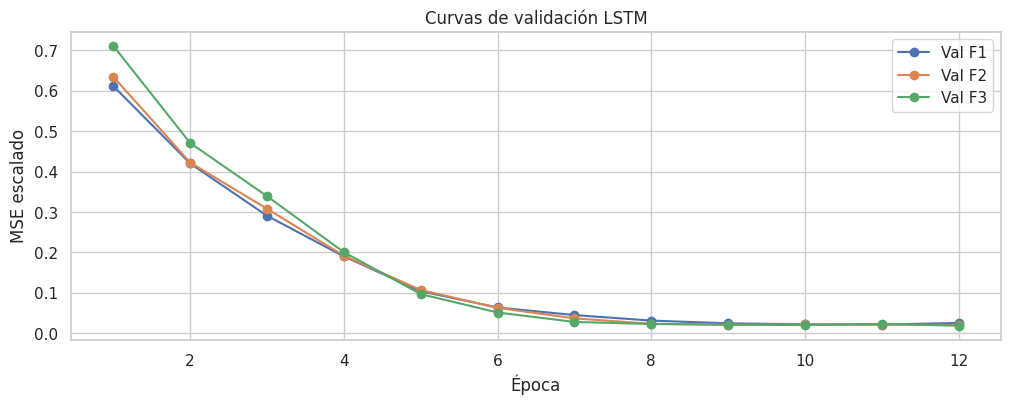

In [36]:
fig,ax=plt.subplots();
for fold,h in histories.items(): ax.plot(h.epoch,h.val_loss,marker="o",label=f"Val F{fold}")
ax.set(title="Curvas de validación LSTM",xlabel="Época",ylabel="MSE escalado"); ax.legend(); plt.show()

### 3.9 Learning rate

Efecto del scheduler.

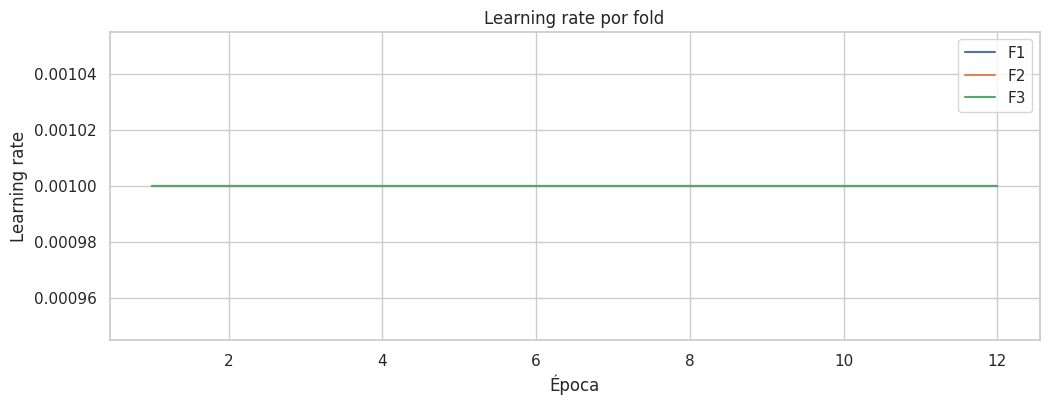

In [37]:
fig,ax=plt.subplots();
for fold,h in histories.items(): ax.step(h.epoch,h.lr,where="post",label=f"F{fold}")
ax.set(title="Learning rate por fold",xlabel="Época",ylabel="Learning rate"); ax.legend(); plt.show()

### 3.10 Comparación por fold

MASE.

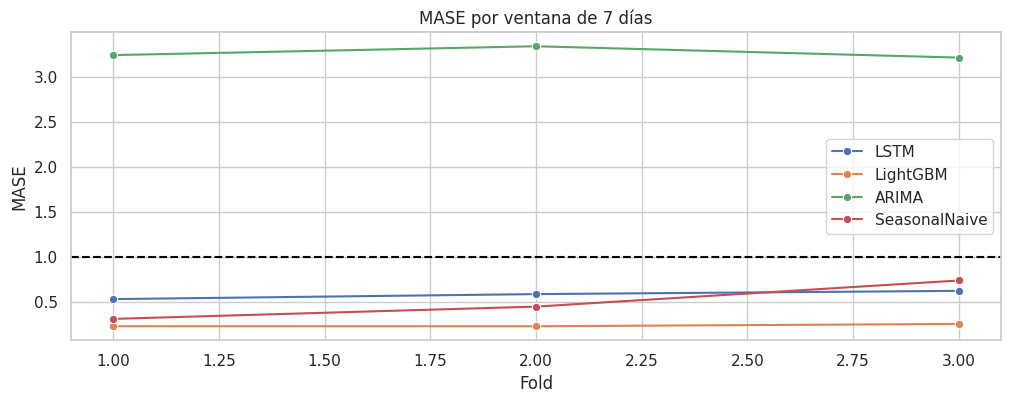

In [38]:
fig,ax=plt.subplots(); sns.lineplot(data=scores,x="fold",y="MASE",hue="model",marker="o",ax=ax); ax.axhline(1,color="black",ls="--"); ax.set(title="MASE por ventana de 7 días",xlabel="Fold",ylabel="MASE"); ax.legend(); plt.show()

### 3.11 Forecast último fold

Zoom.

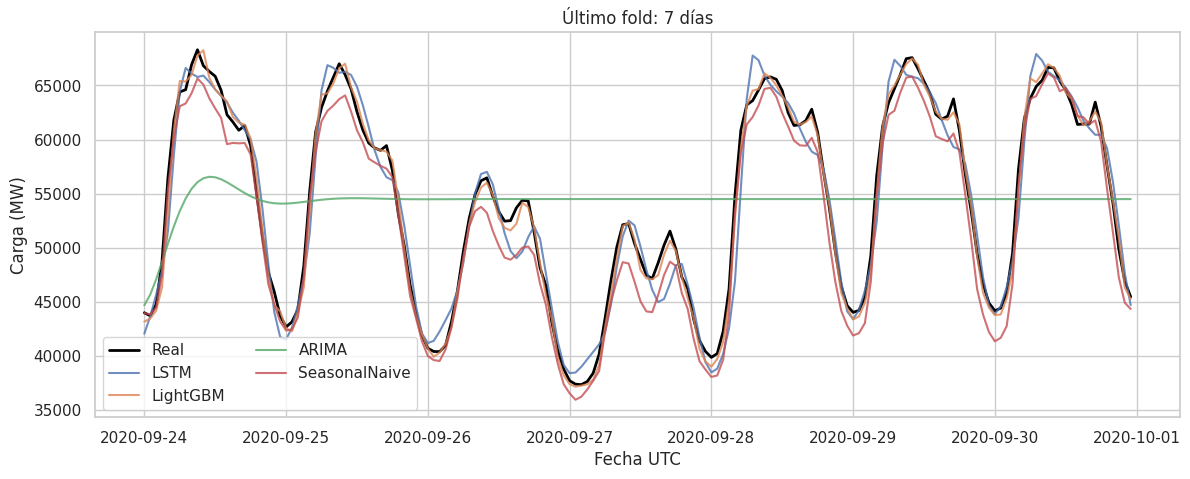

In [39]:
f=folds[-1]; actual=df.iloc[f["test_start"]:f["test_end"]][TARGET]; fig,ax=plt.subplots(figsize=(14,5)); ax.plot(actual.index,actual,color="black",label="Real",lw=2)
for name in ["LSTM","LightGBM","ARIMA","SeasonalNaive"]: ax.plot(actual.index,predictions[(3,name)],label=name,alpha=.8)
ax.set(title="Último fold: 7 días",xlabel="Fecha UTC",ylabel="Carga (MW)"); ax.legend(ncol=2); plt.show()

### 3.12 Coste de modelo

Parámetros LSTM y tamaño conceptual.

In [40]:
# --- Coste del modelo LSTM: parámetros entrenables, features y lookback ---
n_params=sum(p.numel() for p in list(model.parameters())); print("Parámetros LSTM",n_params,"features",len(FEATURES),"lookback",LOOKBACK)

Parámetros LSTM 5153 features 6 lookback 168


## 4. Análisis posterior (post-modeling)

Se diagnostica el modelo con menor MASE medio. Los tests detectan estructura restante; no convierten errores dependientes en iid.

### 4.1 Selección

Modelo por MASE medio.

In [41]:
best=summary.index[0]; print("mejor",best); blocks=[]
for f in folds:
    actual=df.iloc[f["test_start"]:f["test_end"]][TARGET]; blocks.append(pd.DataFrame({"residual":actual-predictions[(f["fold"],best)],"fold":f["fold"]}))
residuals=pd.concat(blocks)

mejor LightGBM


### 4.2 Residuos

En el tiempo.

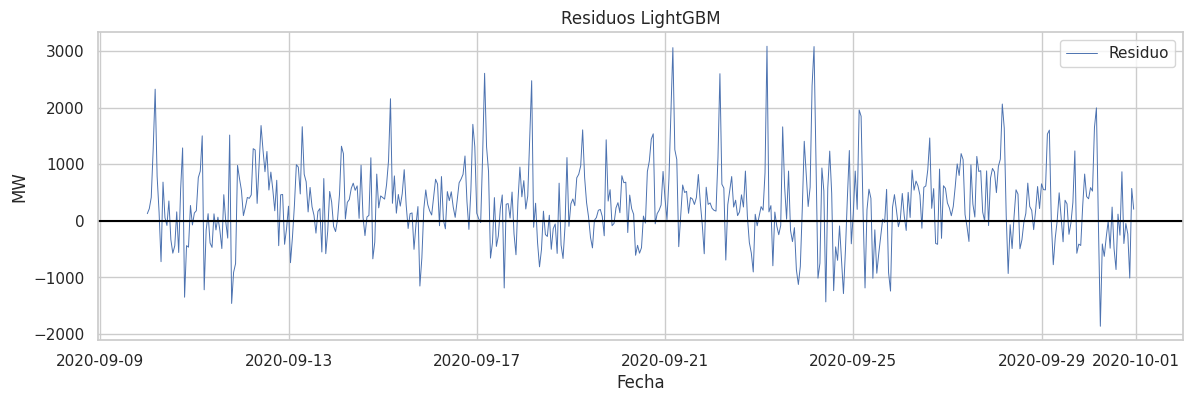

In [42]:
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(residuals.index,residuals.residual,lw=.7,label="Residuo"); ax.axhline(0,color="black"); ax.set(title=f"Residuos {best}",xlabel="Fecha",ylabel="MW"); ax.legend(); plt.show()

### 4.3 Ljung–Box

H₀: no autocorrelación hasta lag 24.

In [43]:
rows=[]
for fold,g in residuals.groupby("fold"):
    lb=acorr_ljungbox(g.residual,lags=[24],return_df=True).iloc[0]; rows.append({"fold":fold,"test":"Ljung-Box","H0":"sin autocorrelación","stat":lb.lb_stat,"p_value":lb.lb_pvalue,"decision":"rechazar H0" if lb.lb_pvalue<.05 else "no rechazar H0"})
pd.DataFrame(rows)

,fold,test,H0,stat,p_value,decision
0,1,Ljung-Box,sin autocorrelación,65.026114,1.206534e-05,rechazar H0
1,2,Ljung-Box,sin autocorrelación,130.929607,1.052637e-16,rechazar H0
2,3,Ljung-Box,sin autocorrelación,78.731553,9.676796e-08,rechazar H0


### 4.4 Normalidad

Jarque–Bera.

In [44]:
jb=jarque_bera(residuals.residual); pd.DataFrame([{"test":"Jarque-Bera","H0":"normalidad","stat":jb[0],"p_value":jb[1],"decision":"rechazar H0" if jb[1]<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,Jarque-Bera,normalidad,91.801605,1.162879e-20,rechazar H0


### 4.5 QQ-plot

Colas.

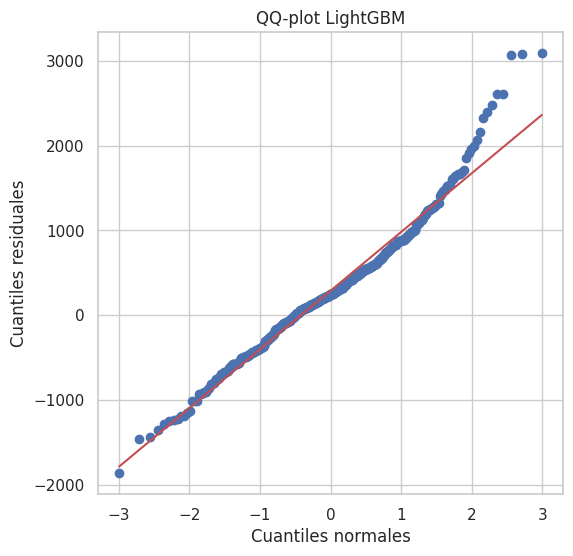

In [45]:
fig,ax=plt.subplots(figsize=(6,6)); stats.probplot(residuals.residual,plot=ax); ax.set(title=f"QQ-plot {best}",xlabel="Cuantiles normales",ylabel="Cuantiles residuales"); plt.show()

### 4.6 ARCH

H₀: homocedasticidad.

In [46]:
a=het_arch(residuals.residual,nlags=24); pd.DataFrame([{"test":"ARCH LM","H0":"homocedasticidad","stat":a[0],"p_value":a[1],"decision":"rechazar H0" if a[1]<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,ARCH LM,homocedasticidad,161.484602,2.364153e-22,rechazar H0


### 4.7 Error por hora

¿Captura picos diarios?

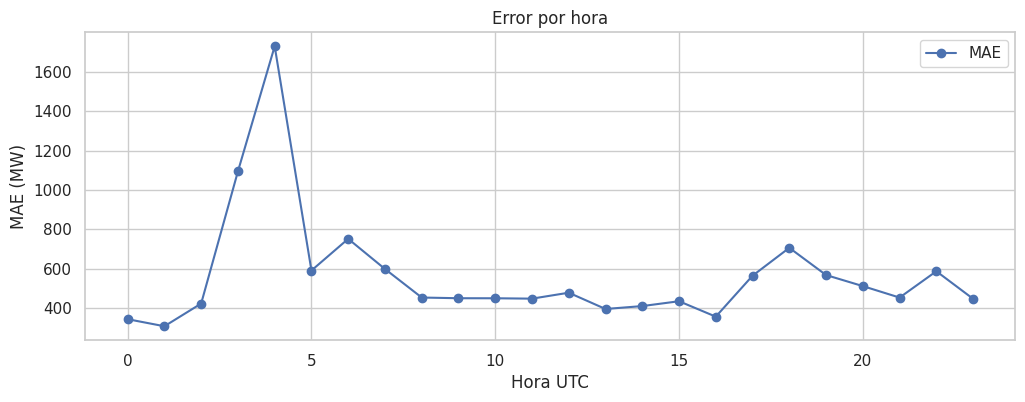

In [47]:
eh=residuals.assign(hour=residuals.index.hour).groupby("hour").residual.apply(lambda x:x.abs().mean()); fig,ax=plt.subplots(); ax.plot(eh.index,eh,marker="o",label="MAE"); ax.set(title="Error por hora",xlabel="Hora UTC",ylabel="MAE (MW)"); ax.legend(); plt.show()

### 4.8 Picos

Pico definido por cuartil superior de cada fold.

In [48]:
segments=[]
for f in folds:
    a=df.iloc[f["test_start"]:f["test_end"]][TARGET]; p=predictions[(f["fold"],best)]; q=a.quantile(.75); segments.append(pd.DataFrame({"segment":np.where(a>=q,"pico","normal"),"abs_error":(a-p).abs()}))
pd.concat(segments).groupby("segment").abs_error.agg(["mean","median","count"])

,mean,median,count
segment,,,
normal,594.487413,448.382662,378
pico,478.420351,452.630531,126


### 4.9 Bias

Por fold.

In [49]:
residuals.groupby("fold").residual.agg(["mean","median","std"])

,mean,median,std
fold,,,
1,314.819992,287.248754,627.711735
2,299.933892,212.645532,716.268794
3,252.649199,226.990234,751.872710


### Anti-patrón de la semana: asumir que deep learning es superior

El sesgo más frecuente al introducir DL es creer que una LSTM ganará por el simple hecho de ser deep learning. Este notebook lo trata como experimento con evaluación justa: idénticos folds, mismas métricas y mismo periodo para todos los modelos (3.7 y 3.10). El resultado es explícito: LightGBM obtiene el menor MASE medio, por delante de la LSTM. La conclusión no es "DL no sirve", sino que la superioridad debe demostrarse bajo el protocolo, no asumirse.

### 4.10 ¿Vale la pena DL?

Tabla de precisión y complejidad.

**Resultado del experimento (mismos folds, mismas condiciones):** LightGBM obtiene el menor MASE medio (0.234), seguido de seasonal naive (0.495), LSTM (0.576) y ARIMA (3.263). La LSTM (5,153 parámetros) no supera a los baselines en este protocolo.

**Decisión ejecutiva:** mantener LightGBM como modelo de producción del operador. Usar LSTM solo si justifica su coste (entrenamiento, memoria, complejidad operativa) con una ganancia de precisión demostrada sobre los mismos folds. La pregunta guía se responde con evidencia: bajo este protocolo, deep learning no justifica su coste frente a un baseline fuerte.

**Nota interpretativa sobre ARIMA.** Un MASE de 3.263 es inusualmente alto, pero esto no significa que ARIMA sea un mal modelo en general: la carga eléctrica alemana, con alta penetración de renovables, tiene una dinámica que un ARIMA univariado (sin covariables) no puede capturar. Aquí ARIMA sirve como *piso de referencia*, no como modelo recomendado — su valor es mostrar que la complejidad adicional de LightGBM está justificada por la estructura del problema (covariables disponibles), no por moda.

In [50]:
# --- Tabla de decisión: precisión vs complejidad para elegir el modelo de producción ---
decision=pd.DataFrame({"model":summary.index,"MASE_mean":summary[("MASE","mean")].values,"requires_sequence_tensor":[m=="LSTM" for m in summary.index],"interpretable_baseline":[m in ["ARIMA","SeasonalNaive"] for m in summary.index]}); decision

,model,MASE_mean,requires_sequence_tensor,interpretable_baseline
0,LightGBM,0.233728,False,False
1,SeasonalNaive,0.494681,False,True
2,LSTM,0.575966,True,False
3,ARIMA,3.263284,False,True


### Checkpoint y checklist de reproducibilidad

**Checkpoint — ¿puedes responder sin mirar atrás?**
1. ¿Qué forma tiene el tensor que recibe la LSTM y qué significa cada dimensión?
2. ¿Por qué el scaler y la imputación se ajustan solo con train?
3. ¿Qué modelo ganó en MASE medio y cuál fue su valor?
4. En una junta de negocio, ¿qué argumentos usarías para no desplegar la LSTM hoy?

**Checklist de reproducibilidad**
- [ ] seed fijada (42) en `random`, `numpy` y `torch` (celda 0.1).
- [ ] Mismo CSV y mismo periodo de laboratorio (últimos 730 días).
- [ ] Folds idénticos para los cuatro modelos.
- [ ] Scaler e imputación ajustados solo con train.
- [ ] Métricas definidas antes de entrenar (MAE, RMSE, MASE, WAPE).
- [ ] Coste reportado (parámetros y segundos de entrenamiento).

## 5. Lecciones metodológicas

1. El scaler se ajusta solo con train.  
2. Tensor 3D = muestras × 168 timesteps × features.  
3. Una semana de validación cubre el ciclo operativo completo.  
4. Early stopping y scheduler reducen sobreajuste, no garantizan superioridad.  
5. DL debe justificar coste frente a LightGBM y seasonal naive.  
6. La evaluación one-step actualizada no equivale a un forecast recursivo de 168 horas.  

**Conexión:** Semana 7 estudia arquitecturas modernas y transferencia entre sensores.

> **Lo que este análisis NO puede afirmar:** que LightGBM es "el mejor modelo" en absoluto — es el mejor *en este dataset, con este protocolo, en estos tres folds*; que la LSTM es inútil — puede ser competitiva en otros dominios, con más historia o patrones no lineales más complejos; que el resultado se extrapola a otros países u horizontes sin validación local; ni que la covariable de pronóstico oficial será igualmente informativa si el operador cambia su metodología.

## 6. Ejercicios propuestos

1. Cambie lookback a 24, 336 y 672.  
2. Evalúe forecast recursivo sin observaciones del test.  
3. Añada embeddings calendario.  
4. Compare GRU y LSTM con igual número de parámetros.  
5. Mida energía/latencia de entrenamiento y serving.

In [51]:
print("Notebook 6 completado.")
print(summary)
print("Mejor modelo:",best)

Notebook 6 completado.
                       MAE                     RMSE                  MASE  \
                      mean         std         mean         std      mean   
model                                                                       
LightGBM        565.470648   33.622482   755.395903   48.198092  0.233728   
SeasonalNaive  1195.720238  522.791466  1417.015108  535.437204  0.494681   
LSTM           1393.401716  106.703745  1891.361038  146.889673  0.575966   
ARIMA          7896.263509  172.470498  8982.154771  174.378659  3.263284   

                          WAPE_pct            
                    std       mean       std  
model                                         
LightGBM       0.014697   1.071651  0.039374  
SeasonalNaive  0.218062   2.251969  0.928333  
LSTM           0.046057   2.639989  0.143663  
ARIMA          0.066281  14.981018  0.602764  
Mejor modelo: LightGBM
